
# Frequency detection by Fourier Transform



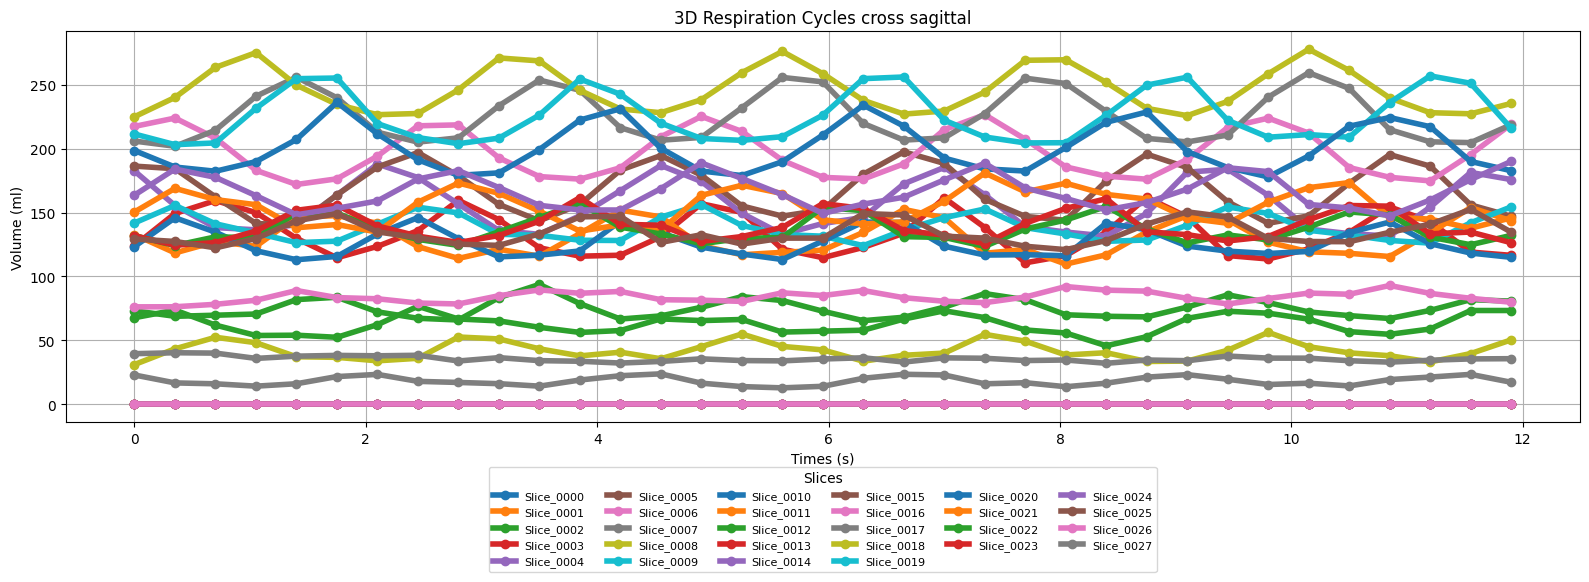

28


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Define the root path containing the folders
root_path = r'F:\Alex-programing\programing\4D_Dynamic_Volume_estimation\Sample_Mask'

# List specific folder names (Slice_0000 to Slice_00028)
folder_names = [f"Slice_{i:04d}" for i in range(0, 28)]

# Initialize dictionaries to store results
results = {}
sum_white_points_per_frame = {}
f=[]

# Process each folder
for folder_name in folder_names:
    folder_path = os.path.join(root_path, folder_name)
    
    # Check if the folder exists
    if not os.path.exists(folder_path):
        print(f"Warning: Folder {folder_path} does not exist.")
        continue
    
    # List all JPG files in the folder
    image_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.jpg')])
    
    if not image_files:
        print(f"Warning: No image files found in {folder_path}.")
        continue  # Skip empty folders
    
    # Initialize storage for the current folder
    frame_indices = []
    white_points = []
    
    # Process each image in the current folder
    for i, file_name in enumerate(image_files):
        file_path = os.path.join(folder_path, file_name)
        
        # Load image in grayscale
        frame = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
        
        if frame is None:
            print(f"Error: Could not load image {file_path}")
            continue
        
        # Count white pixels (value == 255)
        white_count = ((np.sum(frame == 255))* 1.973 * 8)/1000
        
        # Store results
        frame_indices.append(i)
        white_points.append(white_count)
        
        # Update the sum of white points for this frame index across all folders
        if i not in sum_white_points_per_frame:
            sum_white_points_per_frame[i] = 0
        sum_white_points_per_frame[i] += white_count
    f.append(signal.resample(white_points, 35))
    # Save results for this folder
    results[folder_name] = (frame_indices, white_points)

fig, axes = plt.subplots(1, 1, figsize=(16, 6))

# --- Left Plot: 3D cycles ---


for folder_name, (frame_indices, white_points) in results.items():
    frame_time = np.array(frame_indices)*350/1000 # Convert frame indices to time in seconds (350 ms per frame as MRI Protocol)
    plt.plot(frame_time, white_points, marker='o', label=folder_name, linewidth=4.0)

plt.title("3D Respiration Cycles cross sagittal")
plt.xlabel("Times (s)")
plt.ylabel("Volume (ml)")
plt.grid(True)

# Put legend above the plot
plt.legend(
    title="Slices",
    bbox_to_anchor=(0.5, -0.1),  # center top
    loc='upper center',
    ncol=6,
    fontsize=8,
    title_fontsize=10
) 
# # Plot the sum of white points across all folders
# total_frame_indices = sorted(sum_white_points_per_frame.keys())
# total_white_points = [sum_white_points_per_frame[i] for i in total_frame_indices]


# time = np.array(total_frame_indices)  # Assuming each index is 1 frame

# # --- Right Plot: 4D cycle ---
# axes[1].plot(time, total_white_points, marker='o', linestyle='-', color='b')
# axes[1].set_title("4D Respiration Cycle")
# axes[1].set_xlabel("Times")
# axes[1].set_ylabel("Volume")
# axes[1].grid(True)

# Adjust layout and save
plt.tight_layout()
plt.savefig("3D_4D_combined.pdf", format="pdf", bbox_inches="tight")
plt.show()
print(len(f))



The signal on 3D of Fast Fourier Transform

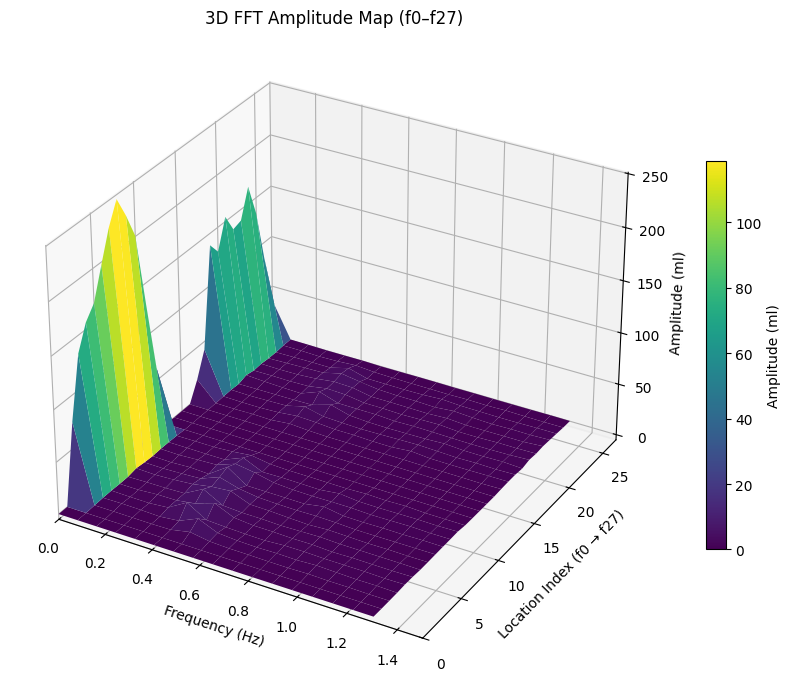

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# === Parameters ===
fs = 1000 / 350  # Hz
num_signals = 28   # f0 to f27

# === FFT setup using f[0] length ===
N = len(f[0])
freqs = np.fft.fftfreq(N, d=1/fs)
positive_freqs = freqs[:N//2]

# === Store FFT magnitudes ===
fft_matrix = np.zeros((num_signals, N//2))

for i in range(num_signals):
    signal = f[i]
    fft_vals = np.fft.fft(signal)
    magnitude = np.abs(fft_vals[:N//2]) / N
    fft_matrix[i, :] = magnitude

# === Create meshgrid ===
FREQ, LOC = np.meshgrid(positive_freqs, np.arange(num_signals))

# === 3D Plot ===
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    FREQ, LOC, fft_matrix,
    cmap='viridis',
    linewidth=0,
    antialiased=True
)

# === Labels ===
ax.set_title("3D FFT Amplitude Map (f0–f27)")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Location Index (f0 → f27)")
ax.set_zlabel("Amplitude (ml)")

ax.set_xlim(0, 1.5)   # respiratory + low-frequency focus
ax.set_ylim(0, num_signals - 1)

fig.colorbar(surf, ax=ax, shrink=0.6, label="Amplitude (ml)")

plt.tight_layout()
plt.savefig("3D_FFT_Frequency_Location_Amplitude.pdf", bbox_inches="tight")
plt.show()


The signal on 3D of Fast Fourier Transform after low cut at 0.001 Hz

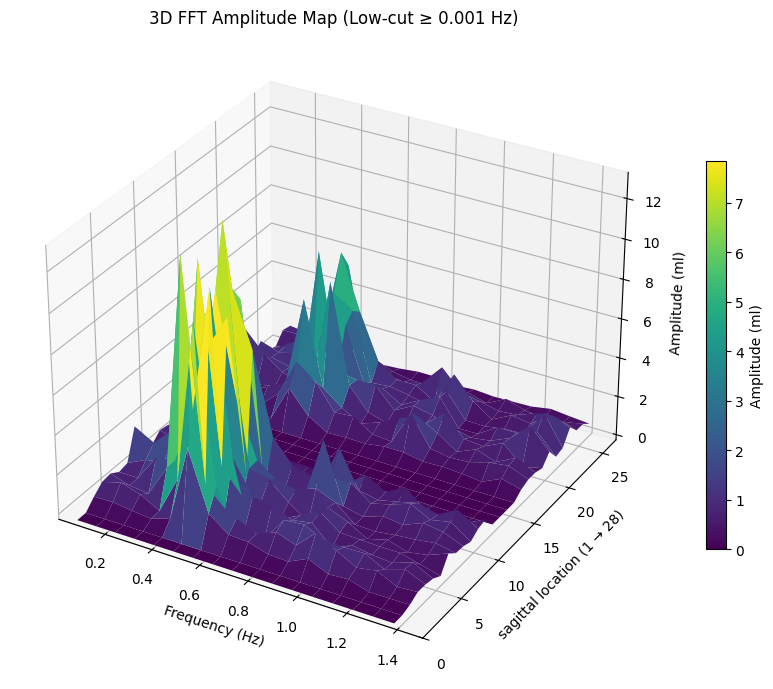

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# === Parameters ===
fs = 1000 / 350          # Hz
num_signals = 28         # f0 to f27
lowcut = 0.001           # Hz

# === FFT setup ===
N = len(f[0])
freqs = np.fft.fftfreq(N, d=1/fs)

# Positive frequencies only
positive_mask = freqs > 0
freqs_pos = freqs[positive_mask]

# Apply low-cut mask
freq_mask = freqs_pos >= lowcut
freqs_selected = freqs_pos[freq_mask]

# === Store FFT magnitudes ===
fft_matrix = np.zeros((num_signals, len(freqs_selected)))

for i in range(num_signals):
    signal = f[i]
    fft_vals = np.fft.fft(signal)
    magnitude = np.abs(fft_vals)[positive_mask] / N
    fft_matrix[i, :] = magnitude[freq_mask]

# === Meshgrid ===
FREQ, LOC = np.meshgrid(freqs_selected, np.arange(num_signals))

# === 3D Plot ===
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    FREQ, LOC, fft_matrix,
    cmap='viridis',
    linewidth=0,
    antialiased=True
)

# === Labels ===
ax.set_title("3D FFT Amplitude Map (Low-cut ≥ 0.001 Hz)")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("sagittal location (1 → 28)")
ax.set_zlabel("Amplitude (ml)")

ax.set_xlim(0.001, 1.5)
ax.set_ylim(0, num_signals - 1)

fig.colorbar(surf, ax=ax, shrink=0.6, label="Amplitude (ml)")

plt.tight_layout()
plt.savefig("3D_FFT_Map_Lowcut_0p001Hz.pdf", bbox_inches="tight")
plt.show()


Analysis 3D FFT from top view remove low frequency signal

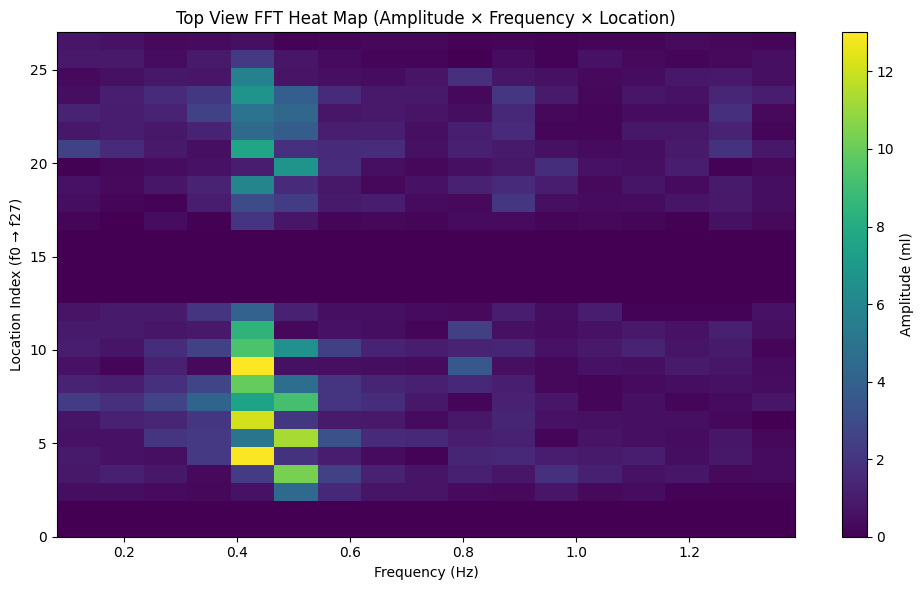

In [64]:
import numpy as np
import matplotlib.pyplot as plt

# === Parameters ===
fs = 1000 / 350          # Hz
num_signals = 28         # f0 to f27
lowcut = -0.0001           # Hz
highcut = 2.0            # Hz (display limit)

# === FFT setup ===
N = len(f[0])
freqs = np.fft.fftfreq(N, d=1/fs)

# Positive frequencies
pos_mask = freqs > 0
freqs_pos = freqs[pos_mask]

# Frequency selection
freq_mask = (freqs_pos >= lowcut) & (freqs_pos <= highcut)
freqs_sel = freqs_pos[freq_mask]

# === FFT magnitude matrix ===
fft_map = np.zeros((num_signals, len(freqs_sel)))

for i in range(num_signals):
    fft_vals = np.fft.fft(f[i])
    mag = np.abs(fft_vals)[pos_mask] / N
    fft_map[i, :] = mag[freq_mask]

# === Plot: Top View Heatmap ===
plt.figure(figsize=(10, 6))

plt.imshow(
    fft_map,
    aspect='auto',
    origin='lower',
    extent=[
        freqs_sel[0], freqs_sel[-1],   # Frequency axis
        0, num_signals - 1              # Location axis
    ],
    cmap='viridis'
)

plt.colorbar(label="Amplitude (ml)")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Location Index (f0 → f27)")
plt.title("Top View FFT Heat Map (Amplitude × Frequency × Location)")

plt.tight_layout()
plt.savefig("Top_View_FFT_Heatmap.pdf", bbox_inches="tight")
plt.show()


Analysis 3D FFT from top view original signal

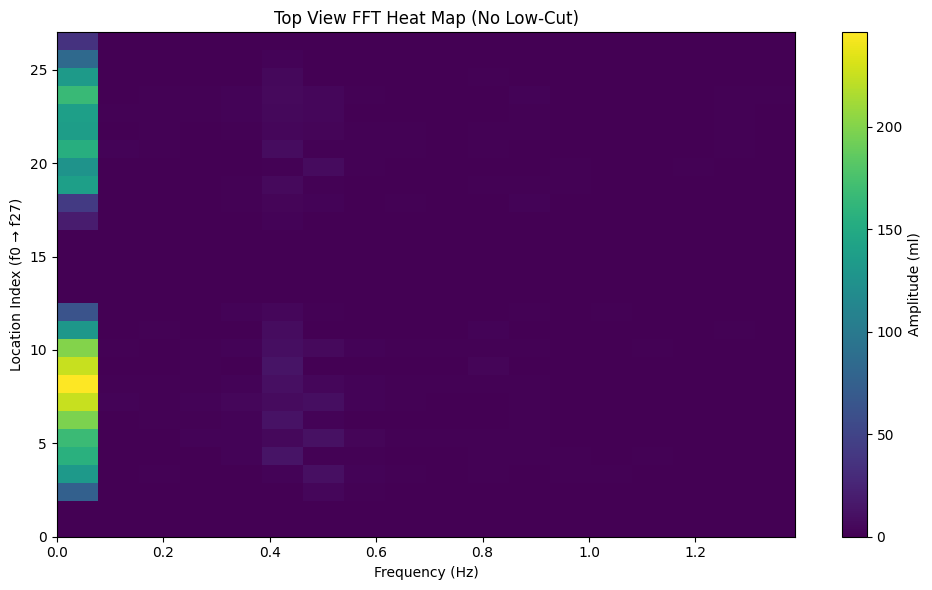

In [65]:
import numpy as np
import matplotlib.pyplot as plt

# === Parameters ===
fs = 1000 / 350          # Hz
num_signals = 28         # f0 to f27
highcut = 2.0            # Hz (display limit only)

# === FFT setup ===
N = len(f[0])
freqs = np.fft.fftfreq(N, d=1/fs)

# Keep positive frequencies INCLUDING DC (0 Hz)
pos_mask = freqs >= 0
freqs_pos = freqs[pos_mask]

# Limit display range (optional)
freq_mask = freqs_pos <= highcut
freqs_sel = freqs_pos[freq_mask]

# === FFT magnitude matrix ===
fft_map = np.zeros((num_signals, len(freqs_sel)))

for i in range(num_signals):
    fft_vals = np.fft.fft(f[i])
    mag = np.abs(fft_vals)[pos_mask] / N
    fft_map[i, :] = mag[freq_mask]

# === Plot: Top View Heatmap ===
plt.figure(figsize=(10, 6))

plt.imshow(
    fft_map,
    aspect='auto',
    origin='lower',
    extent=[
        freqs_sel[0], freqs_sel[-1],   # Frequency axis (includes 0 Hz)
        0, num_signals - 1             # Location axis
    ],
    cmap='viridis'
)

plt.colorbar(label="Amplitude (ml)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Location Index (f0 → f27)")
plt.title("Top View FFT Heat Map (No Low-Cut)")

plt.tight_layout()
plt.savefig("Top_View_FFT_Heatmap_NoLowcut.pdf", bbox_inches="tight")
plt.show()


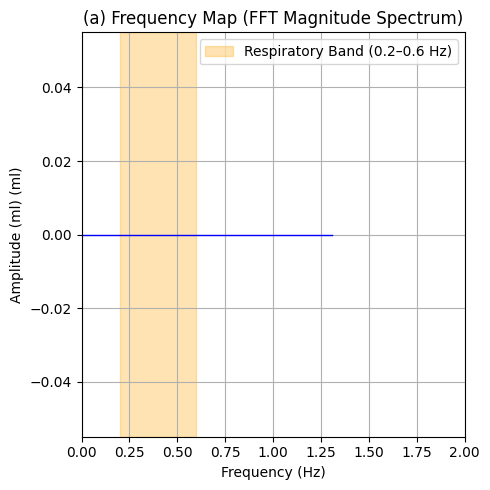

In [66]:
import numpy as np
import matplotlib.pyplot as plt

# === Your signal ===
signal = f[0]
fs = 1000 / 350  # sampling frequency (Hz)

N = len(signal)

# === FFT ===
fft_vals = np.fft.fft(signal)
freqs = np.fft.fftfreq(N, d=1/fs)

# === Use only positive frequencies ===
positive_freqs = freqs[:N//2]
magnitude = np.abs(fft_vals[:N//2]) / N

# === Plot frequency map ===
plt.figure(figsize=(5, 5))
plt.plot(positive_freqs, magnitude, color='blue', linewidth=1)

# Highlight respiratory band
plt.axvspan(0.2, 0.6, color='orange', alpha=0.3, label='Respiratory Band (0.2–0.6 Hz)')

plt.title("(a) Frequency Map (FFT Magnitude Spectrum)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (ml) (ml)")
plt.xlim(0, 2)   # adjust if needed
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig("Frequency_Map_FFT.pdf", bbox_inches="tight")
plt.show()


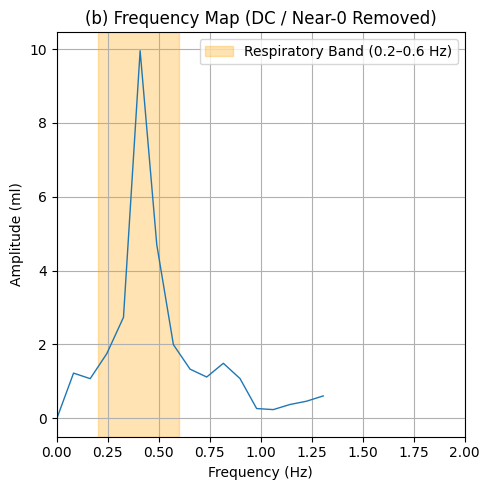

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# === Signal ===
signal = f[8]
fs = 1000 / 350  # Hz
N = len(signal)

# === FFT ===
fft_vals = np.fft.fft(signal)
freqs = np.fft.fftfreq(N, d=1/fs)

# === Remove frequencies close to 0 Hz ===
low_freq_cutoff = 0.0001  # Hz (adjust: 0.03–0.1 typical for respiration)
mask = np.abs(freqs) >= low_freq_cutoff

fft_cleaned = fft_vals * mask

# === Magnitude spectrum (positive frequencies only) ===
positive_freqs = freqs[:N//2]
magnitude = np.abs(fft_cleaned[:N//2]) / N

# === Plot frequency map ===
plt.figure(figsize=(5, 5))
plt.plot(positive_freqs, magnitude, linewidth=1)

plt.axvspan(0.2, 0.6, color='orange', alpha=0.3,
            label='Respiratory Band (0.2–0.6 Hz)')

plt.title("(b) Frequency Map (DC / Near-0 Removed)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (ml)")
plt.xlim(0, 2)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig("Frequency_Map_No_DC.pdf", bbox_inches="tight")
plt.show()


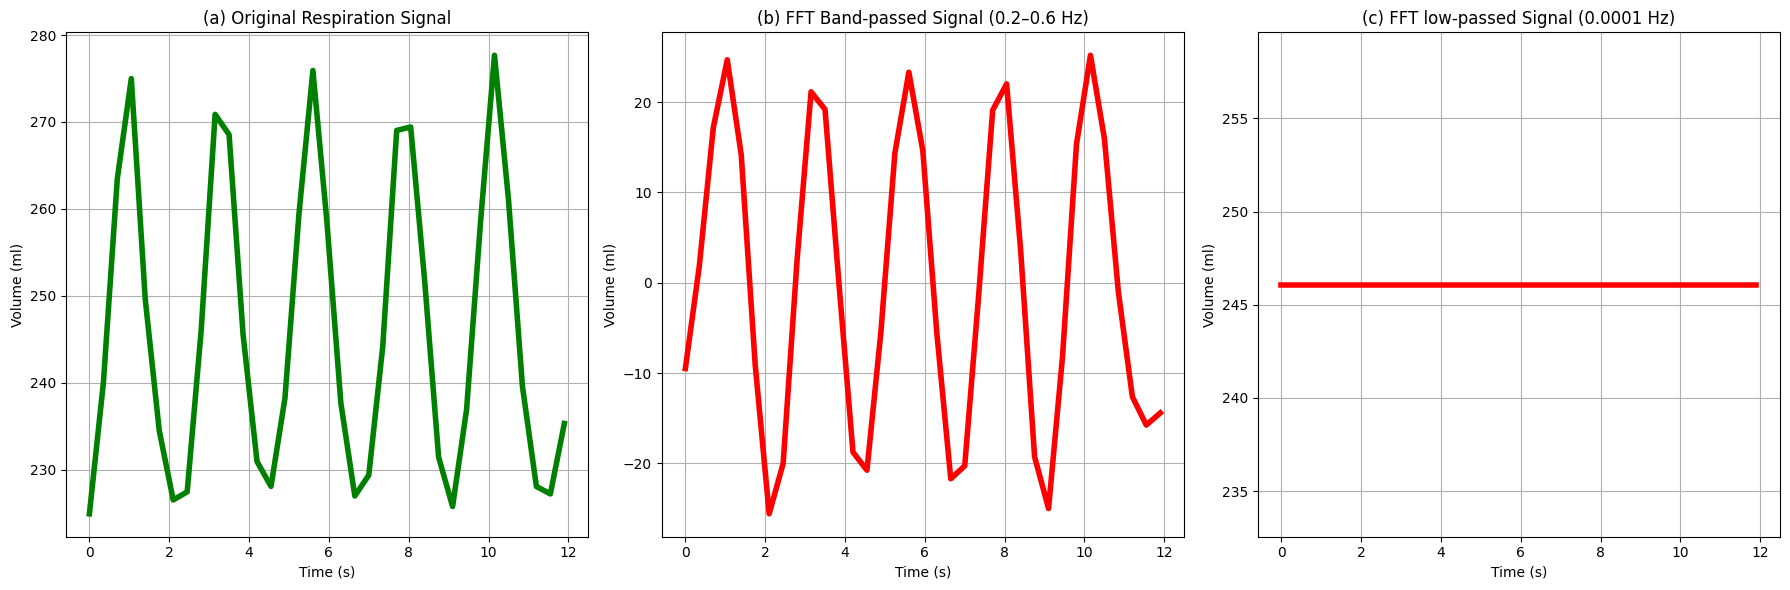

In [191]:
import numpy as np
import matplotlib.pyplot as plt

# === Your actual data array ===
total_white_points = f[8]   # your signal
sample_rate = 1000 / 350   # Hz

# === Time axis ===
N = len(total_white_points)
duration = N / sample_rate
time_original = np.linspace(0, duration, N, endpoint=False)

# === FFT ===
fft_vals = np.fft.fft(total_white_points)
freqs = np.fft.fftfreq(N, d=1/sample_rate)

# === Bandpass mask (0.2–0.6 Hz) ===
cutoff = 0.0001

low_mask = (np.abs(freqs) <= cutoff)
fft_low = fft_vals * low_mask

# === Inverse FFT ===
signal_lowfiltered = np.real(np.fft.ifft(fft_low))

# === Bandpass mask (0.2–0.6 Hz) ===
lowcut = 0.2
highcut = 0.6

band_mask = (np.abs(freqs) >= lowcut) & (np.abs(freqs) <= highcut)

# Apply mask
fft_filtered = fft_vals * band_mask

# === Inverse FFT ===
signal_filtered = np.real(np.fft.ifft(fft_filtered))

# === Plot ===
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.plot(time_original, total_white_points, 'g', linewidth=4.0)
plt.title("(a) Original Respiration Signal")
plt.xlabel("Time (s)")
plt.ylabel("Volume (ml)")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(time_original, signal_lowfiltered, 'red', linewidth=4.0)
plt.title("(c) FFT low-passed Signal (0.0001 Hz)")
plt.ylabel("Volume (ml)")
plt.xlabel("Time (s)")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(time_original, signal_filtered, 'red', linewidth=4.0)
plt.title("(b) FFT Band-passed Signal (0.2–0.6 Hz)")
plt.xlabel("Time (s)")
plt.ylabel("Volume (ml)")
plt.grid(True)

plt.tight_layout()
plt.savefig("FFT_Bandpass_0.2_0.6_Hz.pdf", bbox_inches="tight")
plt.show()


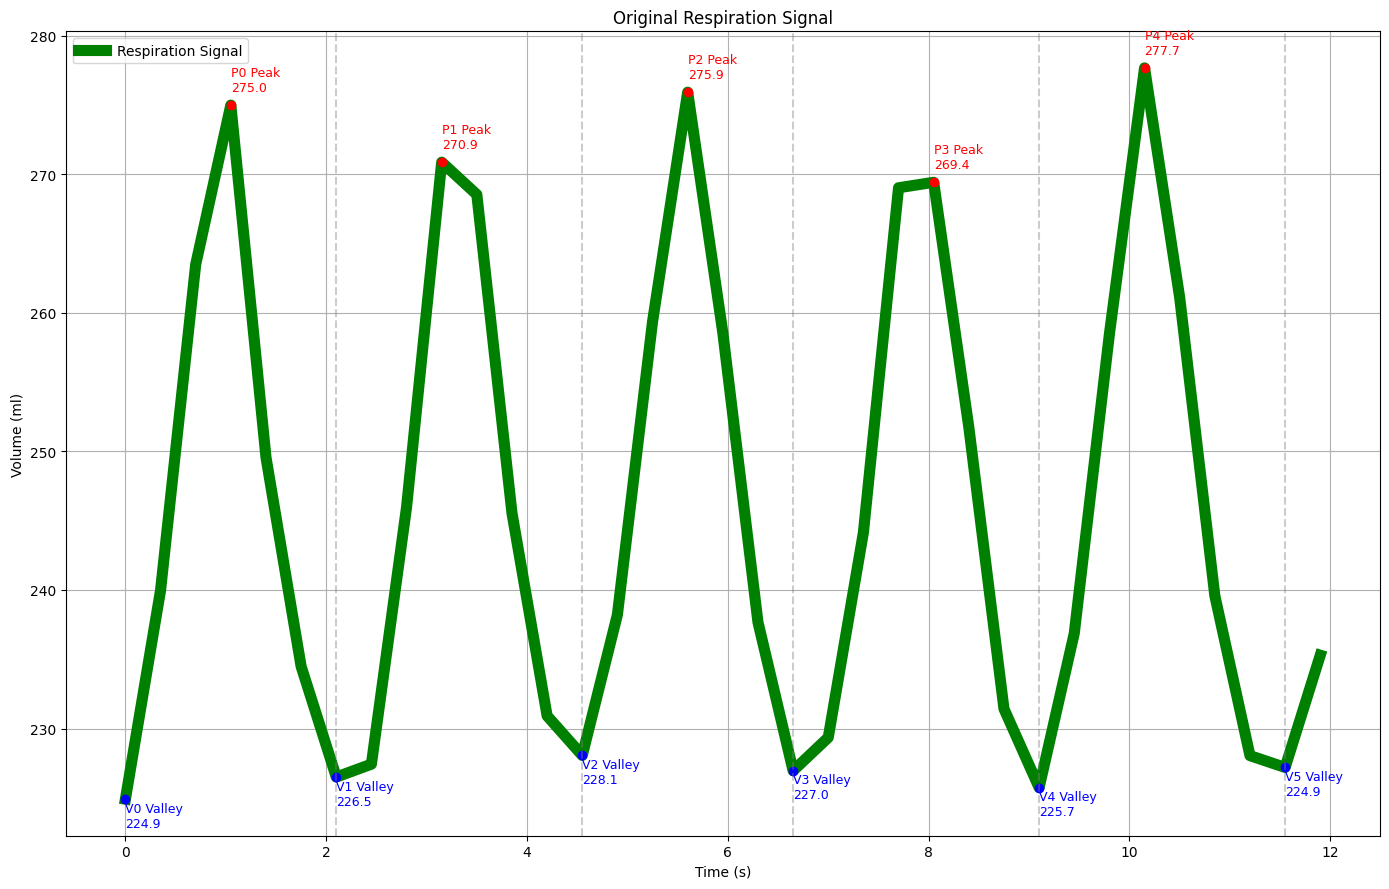

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# === Your actual data array ===
total_white_points = f[8]   # your signal
sample_rate = 1000 / 350   # Hz

# === Signal ===
signal = total_white_points          # or signal_filtered
fs = sample_rate

# === Time axis ===
N = len(signal)
time = np.arange(N) / fs

# === Detect peaks and valleys ===
peaks, _ = find_peaks(signal, distance=fs*1.0)
valleys, _ = find_peaks(-signal, distance=fs*1.0)

valleys = np.sort(valleys)

plt.figure(figsize=(14,9))
# plt.ylim(0, 285)
plt.plot(time, signal, 'g', label='Respiration Signal', linewidth=8)

# === C0: zero-time point ===
t0_idx = 0
t0_val = signal[t0_idx]

plt.plot(time[t0_idx], t0_val, 'bo')
plt.text(time[t0_idx], t0_val - 2,
         f'V0 Valley\n{t0_val:.1f}',
         ha='left', fontsize=9, color='blue')

# === C0 Peak (first detected peak) ===
if len(peaks) > 0:
    c0_peak_idx = peaks[0]
    c0_peak_val = signal[c0_peak_idx]

    plt.plot(time[c0_peak_idx], c0_peak_val, 'ro')
    plt.text(time[c0_peak_idx], c0_peak_val + 1,
             f'P0 Peak\n{c0_peak_val:.1f}',
             ha='left', fontsize=9, color='red')

# === Plot remaining cycles (C1, C2, ...) ===
for i in range(len(valleys) - 1):
    start = valleys[i]
    end = valleys[i + 1]

    p_in_cycle = peaks[(peaks > start) & (peaks < end)]
    if len(p_in_cycle) == 0:
        continue

    peak_idx = p_in_cycle[np.argmax(signal[p_in_cycle])]
    valley_idx = start

    plt.plot(time[valley_idx], signal[valley_idx], 'bo')
    plt.plot(time[peak_idx], signal[peak_idx], 'ro')

    plt.text(time[peak_idx], signal[peak_idx] + 1,
             f'P{i+1} Peak\n{signal[peak_idx]:.1f}',
             ha='left', fontsize=9, color='red')

    plt.text(time[valley_idx], signal[valley_idx] - 2,
             f'V{i+1} Valley\n{signal[valley_idx]:.1f}',
             ha='left', fontsize=9, color='blue')

    plt.axvline(time[valley_idx], color='gray', linestyle='--', alpha=0.4)

# Last boundary
if len(valleys) > 0:
    plt.text(time[valleys[-1]], signal[33] - 2,
         f'V5 Valley\n{t0_val:.1f}',
         ha='left', fontsize=9, color='blue')
    plt.plot(time[valleys[-1]], signal[33], 'bo')
    plt.axvline(time[valleys[-1]], color='gray', linestyle='--', alpha=0.4)

# === Formatting ===
plt.title("Original Respiration Signal")
plt.xlabel("Time (s)")
plt.ylabel("Volume (ml)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [10]:
import numpy as np

indices =  list(range(0, 28))  # f[0], f[2] ... f[27]

for i in indices:
    signal = np.asarray(f[i])

    max_val = np.max(signal)
    min_val = np.min(signal)

    max_idx = np.argmax(signal)
    min_idx = np.argmin(signal)

    print(
        f"f[{i}]: "
        f"max = {max_val:.3f} (index {max_idx}), "
        f"min = {min_val:.3f} (index {min_idx})"
    )


f[0]: max = 0.000 (index 0), min = 0.000 (index 0)
f[1]: max = 0.000 (index 0), min = 0.000 (index 0)
f[2]: max = 93.804 (index 10), min = 65.472 (index 18)
f[3]: max = 161.802 (index 25), min = 110.677 (index 22)
f[4]: max = 187.924 (index 6), min = 131.591 (index 24)
f[5]: max = 197.474 (index 19), min = 139.957 (index 4)
f[6]: max = 226.485 (index 21), min = 171.951 (index 4)
f[7]: max = 259.300 (index 29), min = 201.830 (index 1)
f[8]: max = 277.672 (index 29), min = 224.906 (index 0)
f[9]: max = 256.837 (index 32), min = 203.061 (index 1)
f[10]: max = 236.129 (index 5), min = 177.870 (index 28)
f[11]: max = 153.910 (index 33), min = 109.699 (index 23)
f[12]: max = 76.710 (index 7), min = 45.853 (index 24)
f[13]: max = 0.000 (index 0), min = 0.000 (index 0)
f[14]: max = 0.000 (index 0), min = 0.000 (index 0)
f[15]: max = 0.000 (index 0), min = 0.000 (index 0)
f[16]: max = 0.000 (index 0), min = 0.000 (index 0)
f[17]: max = 23.897 (index 13), min = 12.943 (index 16)
f[18]: max = 56.

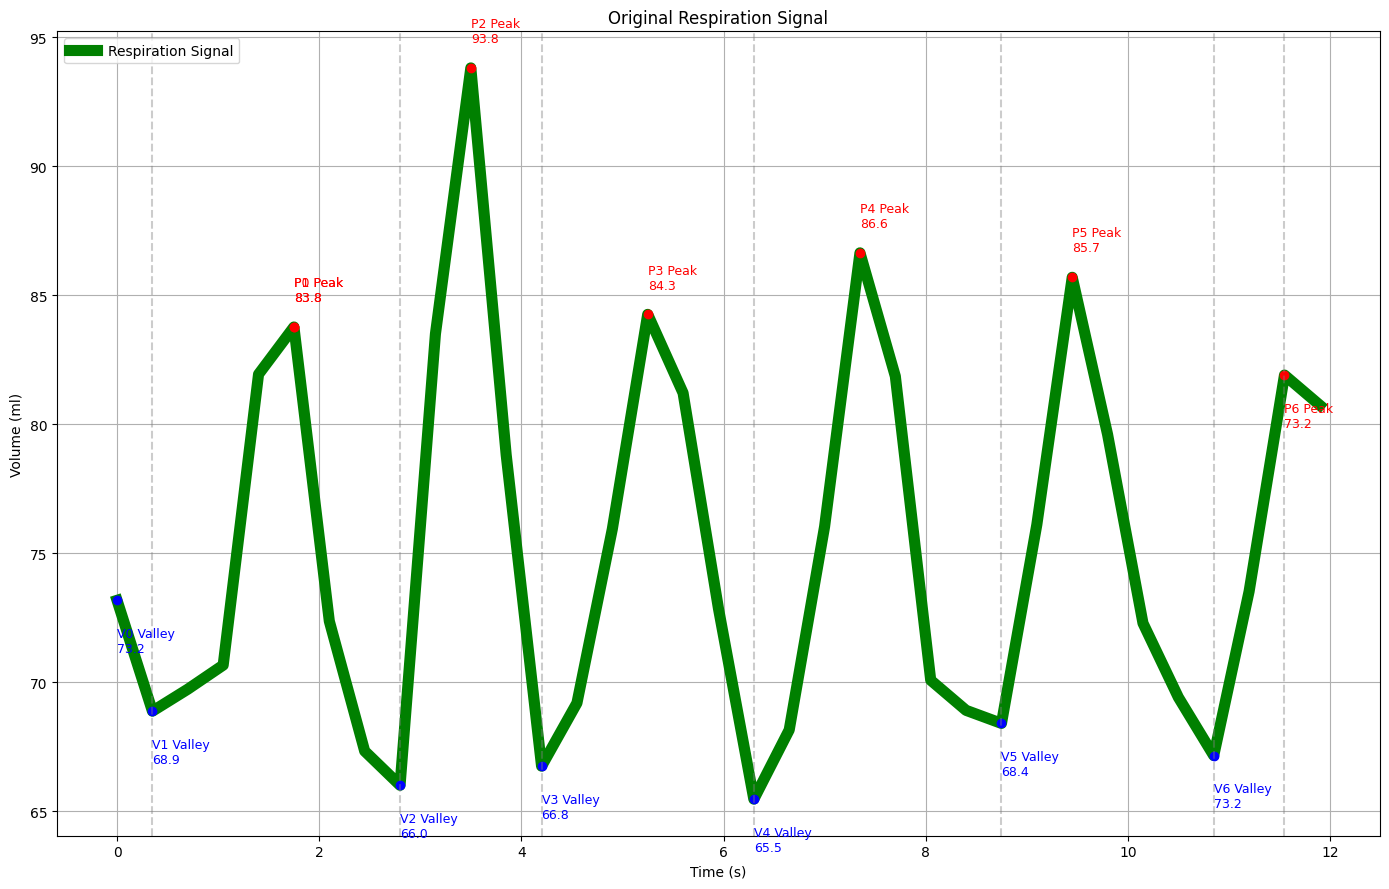

In [188]:
total_white_points = f[2]   # your signal
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# === Signal ===
signal = total_white_points          # or signal_filtered
fs = sample_rate

# === Time axis ===
N = len(signal)
time = np.arange(N) / fs

# === Detect peaks and valleys ===
peaks, _ = find_peaks(signal, distance=fs*1.0)
valleys, _ = find_peaks(-signal, distance=fs*1.0)

valleys = np.sort(valleys)

plt.figure(figsize=(14,9))
# plt.ylim(0, 285)
plt.plot(time, signal, 'g', label='Respiration Signal', linewidth=8)

# === C0: zero-time point ===
t0_idx = 0
t0_val = signal[t0_idx]

plt.plot(time[t0_idx], t0_val, 'bo')
plt.text(time[t0_idx], t0_val - 2,
         f'V0 Valley\n{t0_val:.1f}',
         ha='left', fontsize=9, color='blue')

# === C0 Peak (first detected peak) ===
if len(peaks) > 0:
    c0_peak_idx = peaks[0]
    c0_peak_val = signal[c0_peak_idx]

    plt.plot(time[c0_peak_idx], c0_peak_val, 'ro')
    plt.text(time[c0_peak_idx], c0_peak_val + 1,
             f'P0 Peak\n{c0_peak_val:.1f}',
             ha='left', fontsize=9, color='red')

# === Plot remaining cycles (C1, C2, ...) ===
for i in range(len(valleys) - 1):
    start = valleys[i]
    end = valleys[i + 1]

    p_in_cycle = peaks[(peaks > start) & (peaks < end)]
    if len(p_in_cycle) == 0:
        continue

    peak_idx = p_in_cycle[np.argmax(signal[p_in_cycle])]
    valley_idx = start

    plt.plot(time[valley_idx], signal[valley_idx], 'bo')
    plt.plot(time[peak_idx], signal[peak_idx], 'ro')

    plt.text(time[peak_idx], signal[peak_idx] + 1,
             f'P{i+1} Peak\n{signal[peak_idx]:.1f}',
             ha='left', fontsize=9, color='red')

    plt.text(time[valley_idx], signal[valley_idx] - 2,
             f'V{i+1} Valley\n{signal[valley_idx]:.1f}',
             ha='left', fontsize=9, color='blue')

    plt.axvline(time[valley_idx], color='gray', linestyle='--', alpha=0.4)

# Last boundary
if len(valleys) > 0:
    plt.text(time[valleys[-1]], signal[31] - 2,
         f'V6 Valley\n{t0_val:.1f}',
         ha='left', fontsize=9, color='blue')
    plt.plot(time[valleys[-1]], signal[31], 'bo')
    plt.axvline(time[valleys[-1]], color='gray', linestyle='--', alpha=0.4)
    # Last boundary
if len(peaks) > 0:
    plt.text(time[peaks[-1]], signal[33] - 2,
         f'P6 Peak\n{t0_val:.1f}',
         ha='left', fontsize=9, color='red')
    plt.plot(time[peaks[-1]], signal[33], 'ro')
    plt.axvline(time[peaks[-1]], color='gray', linestyle='--', alpha=0.4)

# === Formatting ===
plt.title("Original Respiration Signal")
plt.xlabel("Time (s)")
plt.ylabel("Volume (ml)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


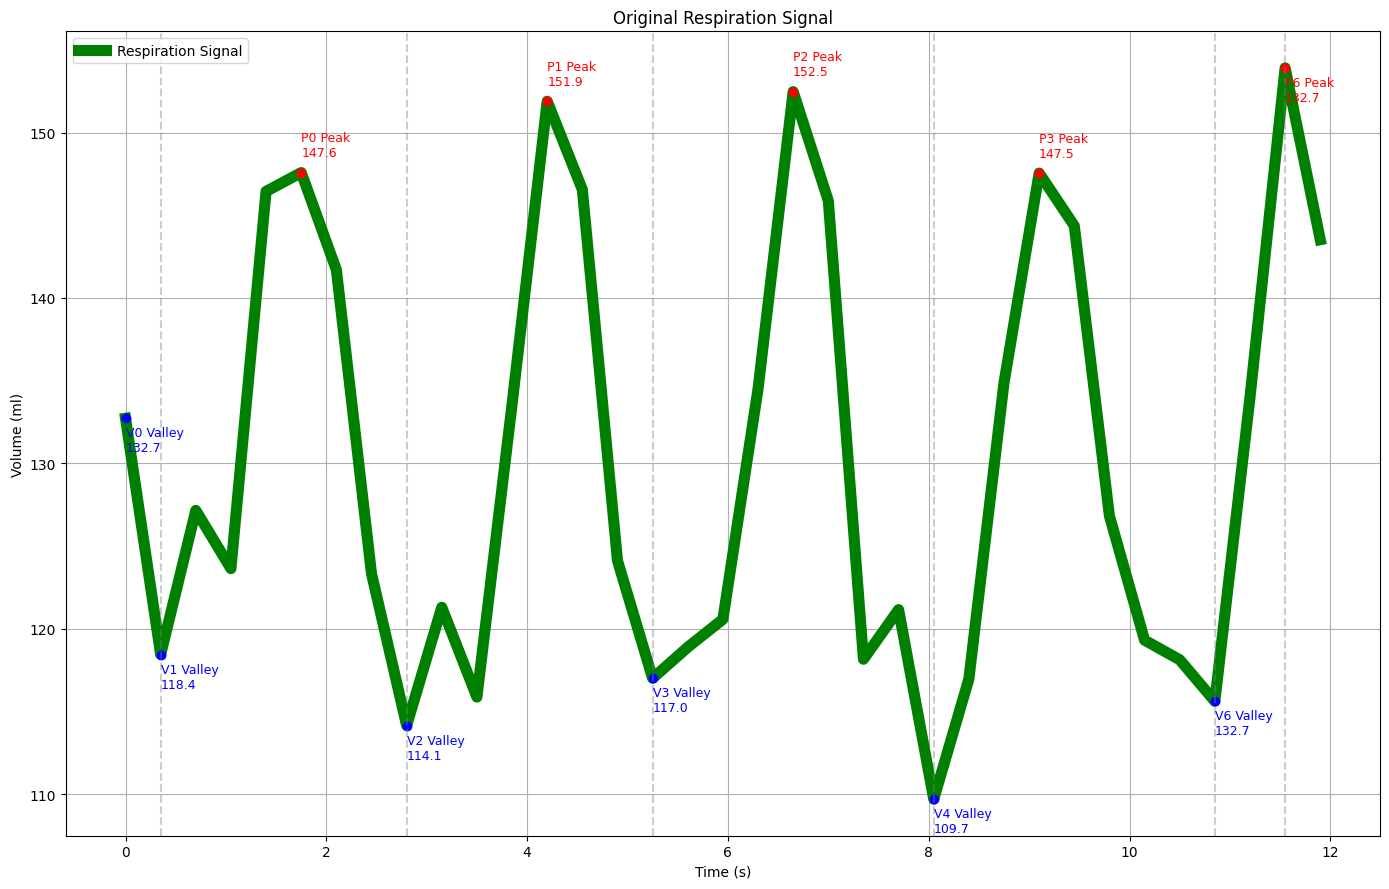

In [187]:
total_white_points = f[11]   # your signal
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# === Signal ===
signal = total_white_points          # or signal_filtered
fs = sample_rate

# === Time axis ===
N = len(signal)
time = np.arange(N) / fs

# === Detect peaks and valleys ===
peaks, _ = find_peaks(signal, distance=fs*1.0)
valleys, _ = find_peaks(-signal, distance=fs*1.0)

valleys = np.sort(valleys)

plt.figure(figsize=(14,9))
# plt.ylim(0, 285)
plt.plot(time, signal, 'g', label='Respiration Signal', linewidth=8)

# === C0: zero-time point ===
t0_idx = 0
t0_val = signal[t0_idx]

plt.plot(time[t0_idx], t0_val, 'bo')
plt.text(time[t0_idx], t0_val - 2,
         f'V0 Valley\n{t0_val:.1f}',
         ha='left', fontsize=9, color='blue')

# === C0 Peak (first detected peak) ===
# if len(peaks) > 0:
#     c0_peak_idx = peaks[0]
#     c0_peak_val = signal[c0_peak_idx]

#     plt.plot(time[c0_peak_idx], c0_peak_val, 'ro')
#     plt.text(time[c0_peak_idx], c0_peak_val + 1,
#              f'P0 Peak\n{c0_peak_val:.1f}',
#              ha='left', fontsize=9, color='red')

# === Plot remaining cycles (C1, C2, ...) ===
for i in range(len(valleys) - 1):
    start = valleys[i]
    end = valleys[i + 1]

    p_in_cycle = peaks[(peaks > start) & (peaks < end)]
    if len(p_in_cycle) == 0:
        continue

    peak_idx = p_in_cycle[np.argmax(signal[p_in_cycle])]
    valley_idx = start

    plt.plot(time[valley_idx], signal[valley_idx], 'bo')
    plt.plot(time[peak_idx], signal[peak_idx], 'ro')

    plt.text(time[peak_idx], signal[peak_idx] + 1,
             f'P{i} Peak\n{signal[peak_idx]:.1f}',
             ha='left', fontsize=9, color='red')

    plt.text(time[valley_idx], signal[valley_idx] - 2,
             f'V{i+1} Valley\n{signal[valley_idx]:.1f}',
             ha='left', fontsize=9, color='blue')

    plt.axvline(time[valley_idx], color='gray', linestyle='--', alpha=0.4)

# Last boundary
if len(valleys) > 0:
    plt.text(time[valleys[-1]], signal[31] - 2,
         f'V6 Valley\n{t0_val:.1f}',
         ha='left', fontsize=9, color='blue')
    plt.plot(time[valleys[-1]], signal[31], 'bo')
    plt.axvline(time[valleys[-1]], color='gray', linestyle='--', alpha=0.4)
    # Last boundary
if len(peaks) > 0:
    plt.text(time[peaks[-1]], signal[33] - 2,
         f'P6 Peak\n{t0_val:.1f}',
         ha='left', fontsize=9, color='red')
    plt.plot(time[peaks[-1]], signal[33], 'ro')
    plt.axvline(time[peaks[-1]], color='gray', linestyle='--', alpha=0.4)

# === Formatting ===
plt.title("Original Respiration Signal")
plt.xlabel("Time (s)")
plt.ylabel("Volume (ml)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# === Signal ===
signal = total_white_points          # or signal_filtered
fs = sample_rate

# === Time axis ===
N = len(signal)
time = np.arange(N) / fs

# === Detect peaks and valleys ===
peaks, _ = find_peaks(signal, distance=fs*1.0)
valleys, _ = find_peaks(-signal, distance=fs*1.0)

valleys = np.sort(valleys)

plt.figure(figsize=(14,9))
# plt.ylim(0, 285)
plt.plot(time, signal, 'g', label='Respiration Signal', linewidth=4)

# === C0: zero-time point ===
t0_idx = 0
t0_val = signal[t0_idx]

plt.plot(time[t0_idx], t0_val, 'bo')
plt.text(time[t0_idx], t0_val - 2,
         f'V0 Valley\n{t0_val:.1f}',
         ha='left', fontsize=9, color='blue')

# === C0 Peak (first detected peak) ===
if len(peaks) > 0:
    c0_peak_idx = peaks[0]
    c0_peak_val = signal[c0_peak_idx]

    plt.plot(time[c0_peak_idx], c0_peak_val, 'ro')
    plt.text(time[c0_peak_idx], c0_peak_val + 1,
             f'P0 Peak\n{c0_peak_val:.1f}',
             ha='left', fontsize=9, color='red')

# === Plot remaining cycles (C1, C2, ...) ===
for i in range(len(valleys) - 1):
    start = valleys[i]
    end = valleys[i + 1]

    p_in_cycle = peaks[(peaks > start) & (peaks < end)]
    if len(p_in_cycle) == 0:
        continue

    peak_idx = p_in_cycle[np.argmax(signal[p_in_cycle])]
    valley_idx = start

    plt.plot(time[valley_idx], signal[valley_idx], 'bo')
    plt.plot(time[peak_idx], signal[peak_idx], 'ro')

    plt.text(time[peak_idx], signal[peak_idx] + 1,
             f'P{i+1} Peak\n{signal[peak_idx]:.1f}',
             ha='left', fontsize=9, color='red')

    plt.text(time[valley_idx], signal[valley_idx] - 2,
             f'V{i+1} Valley\n{signal[valley_idx]:.1f}',
             ha='left', fontsize=9, color='blue')

    plt.axvline(time[valley_idx], color='gray', linestyle='--', alpha=0.4)

# Last boundary
if len(valleys) > 0:
    plt.text(time[valleys[-1]], signal[33] - 2,
         f'V5 Valley\n{t0_val:.1f}',
         ha='left', fontsize=9, color='blue')
    plt.plot(time[valleys[-1]], signal[33], 'bo')
    plt.axvline(time[valleys[-1]], color='gray', linestyle='--', alpha=0.4)

# === Formatting ===
plt.title("Original Respiration Signal")
plt.xlabel("Time (s)")
plt.ylabel("Volume (ml)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
